# SPECT Ordered Subsets Expectation Maximisation Notebook
A notebook to demonstrate the setup and basic OSEM reconstruction of a 2-dimensional dummy image using SIRF's SPECT projector

Authors: Daniel Deidda and Sam Porter  

CCP SyneRBI Synergistic Image Reconstruction Framework (SIRF).  
Copyright 2022 - 2024 National Physical Laboratory  
Copyright 2022 - 2024, 2021 University College London

This is software developed for the Collaborative Computational Project in Synergistic Reconstruction for Biomedical Imaging (http://www.ccpsynerbi.ac.uk/).

SPDX-License-Identifier: Apache-2.0

# What is OSEM?
The following is just a very brief explanation of the concepts behind OSEM.

PET reconstruction is commonly based on the *Maximum Likelihood Estimation (MLE)* principle. The *likelihood* is the probability to observe some measured data given a (known) image. MLE attempts to find the image that maximises this likelihood. This needs to be done iteratively as the system of equations is very non-linear.

A common iterative method uses *Expectation Maximisation*, which we will not explain here. The resulting algorithm is called *MLEM* (or sometimes *EMML*). However, it is rather slow. The most popular method to increase computation speed is to compute every image update based on only a subset of the data. Subsets are nearly always chosen in terms of the "views" (or azimuthal angles). The *Ordered Subsets Expectation Maximisation (OSEM)* cycles through the subsets. More on this in another notebook, but here we just show how to use the SIRF implementation of OSEM.

OSEM is (still) the most common algorithm in use in clinical PET.

# Initial Setup

In [1]:
import os
import glob
import numpy as np

import notebook_setup


from sirf.STIR import show_2D_array
import sirf.STIR as spect
from sirf.Utilities import examples_data_path
from sirf_exercises import exercises_working_path

data_path = examples_data_path('SPECT')

os.chdir(exercises_working_path("SPECT", "OSEM"))

ModuleNotFoundError: No module named 'numpy'

Redirect information, warning and error messages to log files

In [ ]:
msg_red = spect.MessageRedirector('info.txt', 'warnings.txt', 'errors.txt')

Some useful function definitions

In [ ]:
def create_sample_image(image):
    '''fill the image with some simple geometric shapes.'''
    image.fill(0)
    # create a shape
    shape = spect.EllipticCylinder()
    shape.set_length(400)
    shape.set_radii((100, 40))
    shape.set_origin((0, 60, 10))

    # add the shape to the image
    image.add_shape(shape, scale = 1)

    # add another shape
    shape.set_radii((30, 30))
    shape.set_origin((60, -30, 10))
    image.add_shape(shape, scale = 1.5)

    # add another shape
    shape.set_origin((-60, -30, 10))
    image.add_shape(shape, scale = 0.75)

def make_cylindrical_FOV(image):
    """truncate to cylindrical FOV."""
    cyl_filter =spect.TruncateToCylinderProcessor()
    cyl_filter.apply(image)
    return image

def add_noise(proj_data,noise_factor = 1):
    """Add Poission noise to acquisition data."""
    proj_data_arr = proj_data.as_array() / noise_factor
    # Data should be >=0 anyway, but add abs just to be safe
    proj_data_arr = np.abs(proj_data_arr)
    noisy_proj_data_arr = np.random.poisson(proj_data_arr).astype('float32');
    noisy_proj_data = proj_data.clone()
    noisy_proj_data.fill(noisy_proj_data_arr);
    return noisy_proj_data

# Create ground truth and simulated data images

First, we create a template acquisition data object from file

In [ ]:
templ_sino = spect.AcquisitionData(os.path.join(data_path,'template_sinogram.hs'))

We then use this template sinogram to create simple ground truth and attenuation images

You may need to close Figure 1 window to continue...


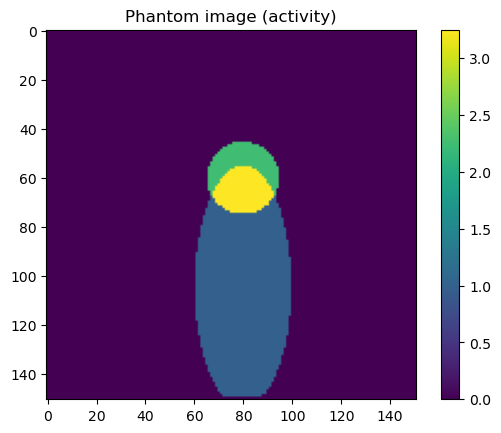

You may need to close Figure 1 window to continue...


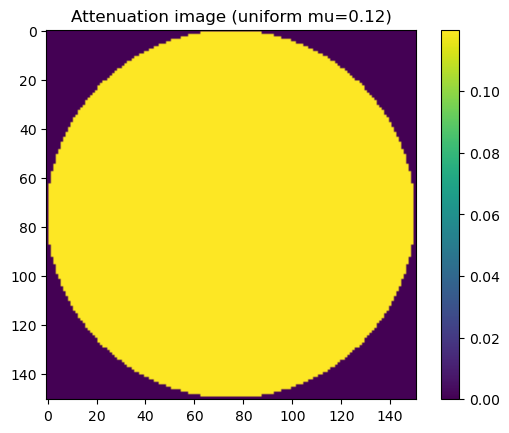

In [ ]:
# --- build a single common image grid (geometry) for EVERYTHING ---
# start from template grid
img_grid = templ_sino.create_uniform_image()

# apply the same zoom to the grid (this changes geometry)
# NOTE: do this ONCE and then clone from it, to keep geometry identical
img_grid = img_grid.zoom_image(zooms=(0.5, 1.0, 1.0))

# --- create ground truth / activity image on this grid ---
image = img_grid.clone()
image.fill(0)
create_sample_image(image)

# --- create attenuation map (uniform mu) on the SAME grid ---
mu = 0.12   # <- WeiMiao style (change if you need another value)
uMap = img_grid.clone()
uMap.fill(mu)

# (optional but recommended) truncate both to cylindrical FOV consistently
# if you already defined make_cylindrical_FOV() above, use it:
image = make_cylindrical_FOV(image)
uMap  = make_cylindrical_FOV(uMap)

# --- show ---
show_2D_array('Phantom image (activity)', image.as_array()[0, :, :])
show_2D_array(f'Attenuation image (uniform mu={mu})', uMap.as_array()[0, :, :])

We then create the acquisition model by first creating an acquisition matrix (SPECTUBMatrix) object, incluidng models of attenuationa and resolution and apply this to a sirf Acquisition Model (AcquisitionModelUsingMatrix) object

In [ ]:

help(spect.SPECTUBMatrix.set_resolution_model)
# select acquisition model that implements the geometric

acq_model_matrix = spect.SPECTUBMatrix();
def get_acquisition_model(uMap,templ_sino,resol_slope, resol_sigma0):
    # forward projection by a ray tracing matrix multiplication

    ### here we add attenuation and set a PSF for the aquisition model ###
    acq_model_matrix.set_attenuation_image(uMap) # add attenuation
    acq_model_matrix.set_resolution_model(resol_slope,resol_sigma0,full_3D=False) #resolution modelling

    acq_model = spect.AcquisitionModelUsingMatrix(acq_model_matrix)
    acq_model.set_up(templ_sino, uMap)
    return acq_model

Help on function set_resolution_model in module sirf.STIR:

set_resolution_model(self, collimator_sigma_0_in_mm, collimator_slope_in_mm, full_3D=True)
    Set the parameters for the depth-dependent resolution model

    The detector and collimator blurring is modelled as a Gaussian with sigma dependent on the
    distance from the collimator.

    sigma_at_depth = collimator_slope * depth_in_mm + collimator sigma 0

    Set slope and sigma_0 to zero to avoid resolution modelling.

    You have to call set_up() after this.



Next, forward project our ground truth image and get the clean sinogram.

Forward projecting phantom -> clean sinogram ...
no additive term added
no unnormalisation applied
no background term added
clean_sino array shape: (1, 1, 126, 150)
You may need to close Figure 1 window to continue...


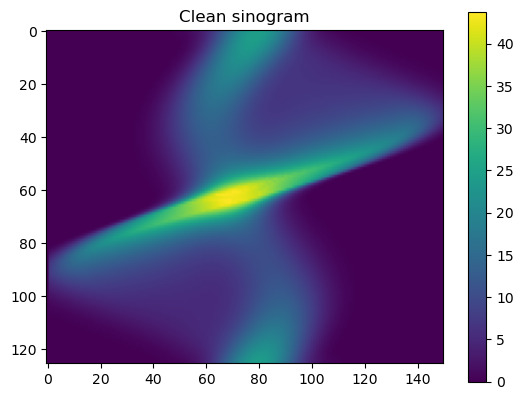

In [ ]:
# build acquisition model (geometry + attenuation + PSF) ----
acq_model = get_acquisition_model(uMap, templ_sino, resol_slope=0.1, resol_sigma0=0.1)

# forward project phantom -> clean sinogram ----
print("Forward projecting phantom -> clean sinogram ...")
clean_sino = templ_sino.get_uniform_copy()   # same shape/metadata as template
acq_model.forward(image, 0, 1, clean_sino)   # forward projection

# visualise a 2D view (one view/angle slice) ----
clean_arr = clean_sino.as_array()
print("clean_sino array shape:", clean_arr.shape)
show_2D_array("Clean sinogram", clean_arr[0, 0, :, :])

Keep clean data as clean branch.

In [ ]:
clean_sino = clean_sino  # already have

Add noise to simulate noisy acquired data. (nosiy data branch)

You may need to close Figure 1 window to continue...


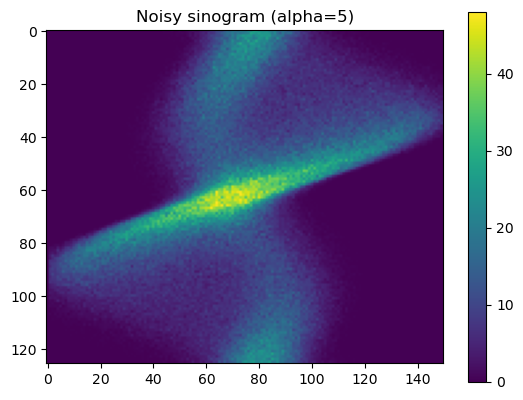

You may need to close Figure 1 window to continue...


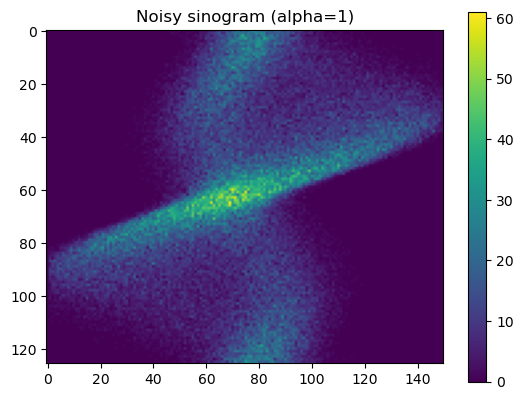

You may need to close Figure 1 window to continue...


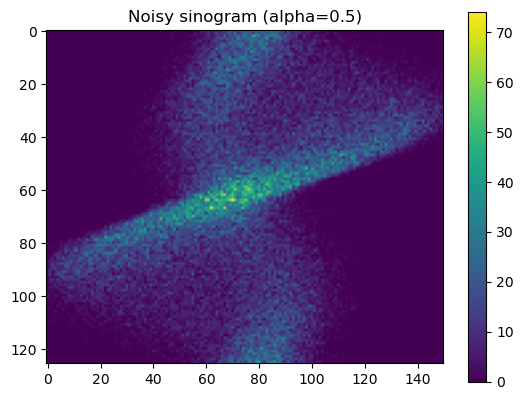

You may need to close Figure 1 window to continue...


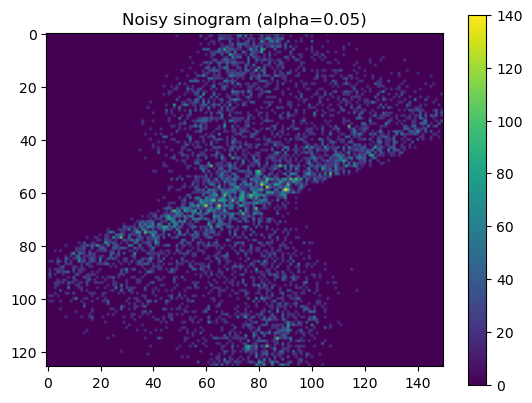

In [ ]:
def add_noise_alpha(clean_proj_data, alpha=1.0):
    """
      - alpha larger -> higher counts -> cleaner (lower relative noise)
      low-count level exhibit proportionally higher variance.
    """
    if alpha <= 0:
        raise ValueError("alpha must be > 0")

    arr = clean_proj_data.as_array().astype(np.float32)
    arr = np.clip(arr, 0, None)  # ensure non-negative

    # scale up counts
    scaled = arr * alpha

    # Poisson sampling
    noisy_counts = np.random.poisson(scaled).astype(np.float32)

    # scale back to original magnitude (so mean stays ~arr)
    noisy_arr = noisy_counts / alpha

    noisy = clean_proj_data.clone()
    noisy.fill(noisy_arr)
    return noisy

alphas = [5, 1, 0.5, 0.05]  # different count level
noisy_sinos = {}

for a in alphas:
    noisy = add_noise_alpha(clean_sino, alpha=a)
    noisy_sinos[a] = noisy

    show_2D_array(f"Noisy sinogram (alpha={a})", noisy.as_array()[0,0,:,:])

## OSEM reconstruction

In [ ]:
def osem_recon_from_sino(
    proj_data,            # AcquisitionData: clean_sino or noisy_sino
    uMap,                 # ImageData: attenuation map (same grid as image)
    templ_sino,           # AcquisitionData template
    resol_slope=0.1,
    resol_sigma0=0.1,
    num_subsets=21,
    num_subiters=42,      # 42 subiters = 2 full iters if subsets=21
    init_image=None,      # ImageData initial estimate
    use_cyl_fov=True,
    title=None
):
    # --- objective function: Poisson log-likelihood ---
    obj_fun = spect.make_Poisson_loglikelihood(proj_data)

    # --- build acquisition model (fresh matrix each time; avoid global state) ---
    mat = spect.SPECTUBMatrix()
    mat.set_attenuation_image(uMap)
    mat.set_resolution_model(resol_slope, resol_sigma0, full_3D=False)
    acq_model = spect.AcquisitionModelUsingMatrix(mat)
    acq_model.set_up(templ_sino, uMap)

    obj_fun.set_acquisition_model(acq_model)

    # --- OSEM reconstructor ---
    recon = spect.OSMAPOSLReconstructor()
    recon.set_objective_function(obj_fun)
    recon.set_num_subsets(num_subsets)
    recon.set_num_subiterations(num_subiters)

    # --- init image ---
    if init_image is None:
        init_image = uMap.get_uniform_copy(1.0)  # same grid as uMap
    if use_cyl_fov:
        init_image = make_cylindrical_FOV(init_image)

    recon.set_up(init_image)
    recon.reconstruct(init_image)

    out = recon.get_current_estimate()
    if title is not None:
        show_2D_array(title, out.as_array()[0,:,:])
    return out

OSEM reconstruction for clean sinogram.

You may need to close Figure 1 window to continue...


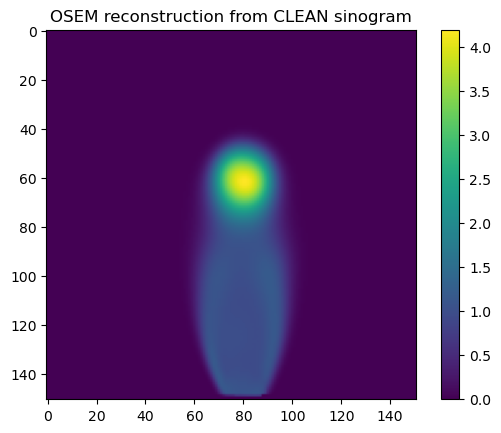

In [ ]:
recon_clean = osem_recon_from_sino(
    clean_sino,
    uMap=uMap,
    templ_sino=templ_sino,
    num_subsets=21,
    num_subiters=42,
    resol_slope=0.1,
    resol_sigma0=0.1,
    title="OSEM reconstruction from CLEAN sinogram"
)

OSEM reconstruction for noisy sinogram.

You may need to close Figure 1 window to continue...


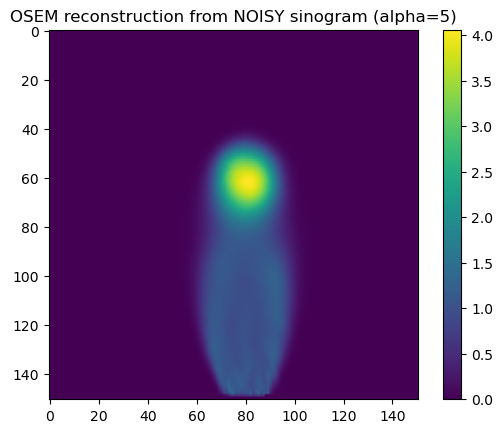

You may need to close Figure 1 window to continue...


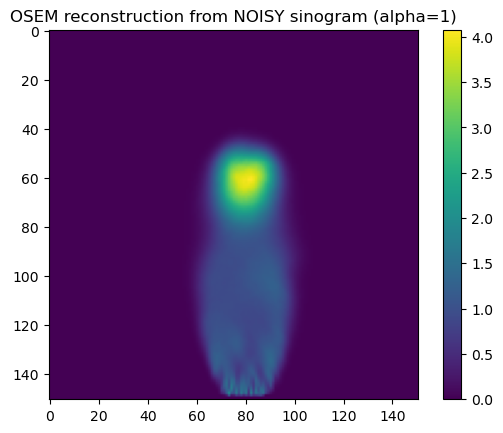

You may need to close Figure 1 window to continue...


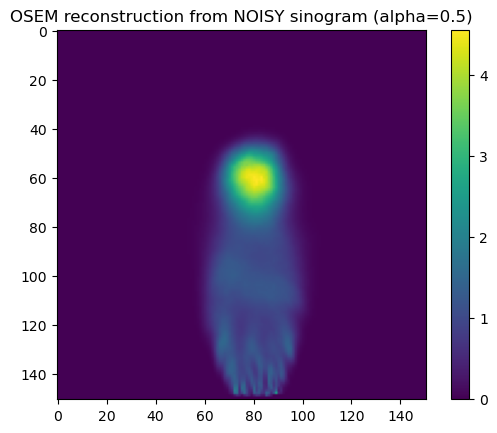

You may need to close Figure 1 window to continue...


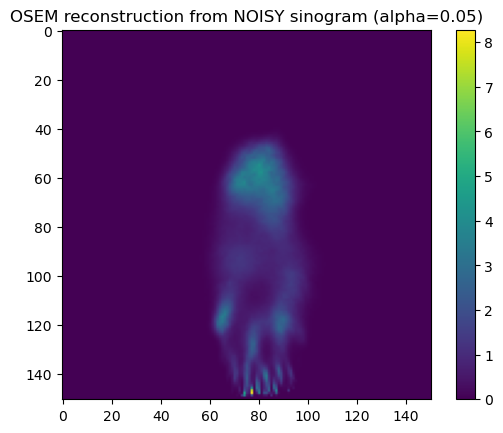

In [ ]:
recons_noisy = {}

for a, sino in noisy_sinos.items():
    recons_noisy[a] = osem_recon_from_sino(
        sino,
        uMap=uMap,
        templ_sino=templ_sino,
        num_subsets=21,
        num_subiters=42,
        resol_slope=0.1,
        resol_sigma0=0.1,
        title=f"OSEM reconstruction from NOISY sinogram (alpha={a})"
    )

In [ ]:
import os
print("CWD =", os.getcwd())
print("files here =", os.listdir(".")[:50])

CWD = /workspaces/SIRF-Exercises/data/working_folder/SPECT/OSEM
files here = ['tmp_3_1769339870379.s', 'tmp_2_1769339870187.hs', 'tmp_1_1769305444649.s', 'tmp_4_1769338889406.hs', 'tmp_19_1769305395155.hs', 'tmp_5_1769338889612.hs', 'tmp_1_1769304744720.hs', 'tmp_4_1769339870641.hs', 'tmp_4_1769306268127.s', 'tmp_4_1769338889406.s', 'tmp_5_1769339870958.s', 'tmp_1_1769303620794.s', 'tmp_1_1769306210960.s', 'tmp_16_1769305369649.hs', 'tmp_18_1769305394932.hs', 'tmp_3_1769305454693.s', 'tmp_1_1769338872416.s', 'tmp_2_1769338888818.hs', 'tmp_2_1769304749792.s', 'tmp_3_1769339870379.hs', 'tmp_1_1769339854330.hs', 'tmp_1_1769338872416.hs', 'outputs', 'tmp_1_1769339854330.s', 'errors.txt', 'tmp_16_1769305369649.s', 'tmp_5_1769305455221.hs', 'tmp_2_1769304749792.hs', 'tmp_2_1769305454485.hs', 'tmp_5_1769338889612.s', 'tmp_2_1769339870187.s', 'tmp_19_1769305395155.s', 'tmp_1_1769306210960.hs', 'tmp_1_1769304744720.s', 'tmp_2_1769306267598.s', 'tmp_2_1769338888818.s', 'tmp_4_1769305455000.s', '

In [ ]:
import os, numpy as np

out_dir = "outputs"
os.makedirs(out_dir, exist_ok=True)

phantom = image.as_array().astype(np.float32)     # activity ground truth (你的 phantom image)
umap    = uMap.as_array().astype(np.float32)      # attenuation map

clean_sino_arr = clean_sino.as_array().astype(np.float32)
recon_clean_arr = recon_clean.as_array().astype(np.float32)

# noisy sinograms + noisy reconstructions
alphas = sorted(list(noisy_sinos.keys()))
noisy_sino_stack = np.stack([noisy_sinos[a].as_array() for a in alphas]).astype(np.float32)
noisy_recon_stack = np.stack([recons_noisy[a].as_array() for a in alphas]).astype(np.float32)

# Save to .npz file
save_path = os.path.join(out_dir, "weimiao_spect_osem_dataset.npz")

np.savez_compressed(
    save_path,
    alphas=np.array(alphas, dtype=np.float32),

    phantom=phantom,
    umap=umap,

    clean_sinogram=clean_sino_arr,
    noisy_sinograms=noisy_sino_stack,

    recon_clean=recon_clean_arr,
    recon_noisy=noisy_recon_stack,

    # （可选）把关键超参数也存进去，保证可复现实验
    meta=np.array([
        "num_subsets=21",
        "num_subiters=42",
        "resol_slope=0.1",
        "resol_sigma0=0.1",
        "noise: Poisson( alpha * y_clean ) / alpha"
    ], dtype=object)
)

print("Saved to:", save_path)
print("alphas:", alphas)
print("phantom shape:", phantom.shape)
print("clean_sinogram shape:", clean_sino_arr.shape)
print("noisy_sinograms stack shape:", noisy_sino_stack.shape, "  (A, ...)")
print("recon_noisy stack shape:", noisy_recon_stack.shape, "  (A, ...)")

Saved to: outputs/weimiao_spect_osem_dataset.npz
alphas: [0.05, 0.5, 1, 5]
phantom shape: (1, 151, 151)
clean_sinogram shape: (1, 1, 126, 150)
noisy_sinograms stack shape: (4, 1, 1, 126, 150)   (A, ...)
recon_noisy stack shape: (4, 1, 151, 151)   (A, ...)


In [ ]:
import numpy as np

p = "outputs/weimiao_spect_osem_dataset.npz"  # 你实际保存的路径
d = np.load(p, allow_pickle=True)

print("keys:", d.files)
for k in d.files:
    a = d[k]
    print(k, type(a), getattr(a, "dtype", None), getattr(a, "shape", None))

keys: ['alphas', 'phantom', 'umap', 'clean_sinogram', 'noisy_sinograms', 'recon_clean', 'recon_noisy', 'meta']
alphas <class 'numpy.ndarray'> float32 (4,)
phantom <class 'numpy.ndarray'> float32 (1, 151, 151)
umap <class 'numpy.ndarray'> float32 (1, 151, 151)
clean_sinogram <class 'numpy.ndarray'> float32 (1, 1, 126, 150)
noisy_sinograms <class 'numpy.ndarray'> float32 (4, 1, 1, 126, 150)
recon_clean <class 'numpy.ndarray'> float32 (1, 151, 151)
recon_noisy <class 'numpy.ndarray'> float32 (4, 1, 151, 151)
meta <class 'numpy.ndarray'> object (5,)


Export training pairs.

In [ ]:
import os, numpy as np

# 统一放到 working_folder 的 outputs（你现在就在这里）
out_dir = "outputs/unet_pairs"
os.makedirs(out_dir, exist_ok=True)

# target: clean OSEM recon
Y = recon_clean.as_array().astype(np.float32)      # (Z,Y,X) 可能 Z=1
Y = Y[None, ...]                                   # -> (C=1,Z,Y,X)

# inputs: noisy OSEM recon for each alpha
alphas = sorted(list(recons_noisy.keys()))
X_list = []
for a in alphas:
    X = recons_noisy[a].as_array().astype(np.float32)
    X_list.append(X)

X = np.stack(X_list, axis=0)                       # (N,Z,Y,X)
X = X[:, None, ...]                                 # -> (N,C=1,Z,Y,X)

np.savez_compressed(
    os.path.join(out_dir, "train_pairs.npz"),
    X=X,
    Y=np.repeat(Y[None, ...], X.shape[0], axis=0),  # (N,1,Z,Y,X) 每个alpha共享同一target
    alphas=np.array(alphas, dtype=np.float32)
)

print("Saved:", os.path.join(out_dir, "train_pairs.npz"))
print("X shape:", X.shape, "Y shape:", (np.repeat(Y[None, ...], X.shape[0], axis=0)).shape)
print("alphas:", alphas)

Saved: outputs/unet_pairs/train_pairs.npz
X shape: (4, 1, 1, 151, 151) Y shape: (4, 1, 1, 151, 151)
alphas: [0.05, 0.5, 1, 5]


Build Dataset.

In [ ]:
import numpy as np
d = np.load("outputs/unet_pairs/train_pairs.npz")
X = d["X"]   # (N,1,Z,Y,X)
Y = d["Y"]

# 简单归一化（先用每个样本的 max）
X = X / (X.max(axis=(2,3,4), keepdims=True) + 1e-8)
Y = Y / (Y.max(axis=(2,3,4), keepdims=True) + 1e-8)

print(X.shape, Y.shape)

(4, 1, 1, 151, 151) (4, 1, 1, 151, 151)


In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# split: 3 train, 1 val（你也可以自己换）
train_idx = np.array([0,1,2])
val_idx   = np.array([3])

X_train, Y_train = X[train_idx], Y[train_idx]
X_val,   Y_val   = X[val_idx],   Y[val_idx]

# repeat train to make steps meaningful
rep = 200  # 3*200=600 个“训练样本”，够跑 baseline
X_train_rep = np.repeat(X_train, rep, axis=0)
Y_train_rep = np.repeat(Y_train, rep, axis=0)

class PairDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X).float()
        self.Y = torch.from_numpy(Y).float()
    def __len__(self): return self.X.shape[0]
    def __getitem__(self, i): return self.X[i], self.Y[i]

batch_size = 4
train_loader = DataLoader(PairDataset(X_train_rep, Y_train_rep), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(PairDataset(X_val, Y_val), batch_size=1, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device, "train batches:", len(train_loader), "val batches:", len(val_loader))

device: cpu train batches: 150 val batches: 1


Minimalist 3D U-Net

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvBlock3D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, padding=1),
            nn.InstanceNorm3d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, 3, padding=1),
            nn.InstanceNorm3d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)

class UNet3D_Aniso(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base=16):
        super().__init__()
        self.enc1 = ConvBlock3D(in_ch, base)
        self.down1 = nn.Conv3d(base, base*2, kernel_size=(1,2,2), stride=(1,2,2))
        self.enc2 = ConvBlock3D(base*2, base*2)

        self.down2 = nn.Conv3d(base*2, base*4, kernel_size=(1,2,2), stride=(1,2,2))
        self.bott = ConvBlock3D(base*4, base*4)

        self.up2 = nn.ConvTranspose3d(base*4, base*2, kernel_size=(1,2,2), stride=(1,2,2))
        self.dec2 = ConvBlock3D(base*4, base*2)

        self.up1 = nn.ConvTranspose3d(base*2, base, kernel_size=(1,2,2), stride=(1,2,2))
        self.dec1 = ConvBlock3D(base*2, base)

        self.out = nn.Conv3d(base, out_ch, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.down1(e1))
        b  = self.bott(self.down2(e2))

        u2 = self.up2(b)
        if u2.shape[-2:] != e2.shape[-2:]:
            u2 = F.interpolate(u2, size=(u2.shape[-3], e2.shape[-2], e2.shape[-1]),
                               mode="trilinear", align_corners=False)
        d2 = self.dec2(torch.cat([u2, e2], dim=1))

        u1 = self.up1(d2)
        if u1.shape[-2:] != e1.shape[-2:]:
            u1 = F.interpolate(u1, size=(u1.shape[-3], e1.shape[-2], e1.shape[-1]),
                               mode="trilinear", align_corners=False)
        d1 = self.dec1(torch.cat([u1, e1], dim=1))

        return self.out(d1)

model = UNet3D_Aniso(base=16).to(device)
print("params:", sum(p.numel() for p in model.parameters())/1e6, "M")

params: 0.408465 M


In [ ]:
import torch
from tqdm.auto import tqdm

loss_fn = torch.nn.L1Loss()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

def eval_loss(loader):
    model.eval()
    tot, n = 0.0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            tot += loss.item() * xb.size(0)
            n += xb.size(0)
    return tot / max(1, n)

epochs = 10
for ep in range(1, epochs + 1):
    model.train()
    tot_train, n_train = 0.0, 0

    pbar = tqdm(train_loader, desc=f"epoch {ep}/{epochs}", leave=False)
    for xb, yb in pbar:
        xb, yb = xb.to(device), yb.to(device)

        opt.zero_grad(set_to_none=True)
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        opt.step()

        # accumulate epoch train loss (weighted by batch size)
        bs = xb.size(0)
        tot_train += loss.item() * bs
        n_train += bs

        # show step loss in progress bar
        pbar.set_postfix(train_L1=float(loss.item()))

    train_L1 = tot_train / max(1, n_train)
    val_L1 = eval_loss(val_loader)
    print(f"epoch {ep:02d} | train L1: {train_L1:.6f} | val L1: {val_L1:.6f}")

epoch 1/10:   0%|          | 0/150 [00:00<?, ?it/s]

epoch 01 | train L1: 0.012547 | val L1: 0.006632


epoch 2/10:   0%|          | 0/150 [00:00<?, ?it/s]

epoch 02 | train L1: 0.004648 | val L1: 0.004002


epoch 3/10:   0%|          | 0/150 [00:00<?, ?it/s]

...

epoch 08 | train L1: 0.001616 | val L1: 0.005410


epoch 9/10:   0%|          | 0/150 [00:00<?, ?it/s]

epoch 09 | train L1: 0.001627 | val L1: 0.003010


epoch 10/10:   0%|          | 0/150 [00:00<?, ?it/s]

epoch 10 | train L1: 0.001677 | val L1: 0.004150


You may need to close Figure 1 window to continue...


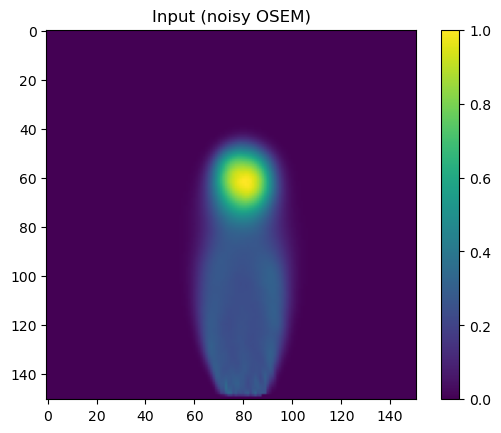

You may need to close Figure 1 window to continue...


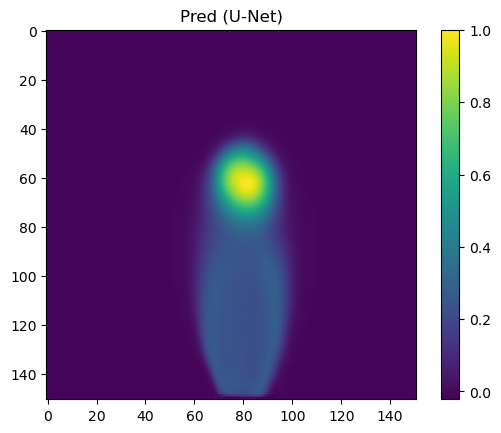

You may need to close Figure 1 window to continue...


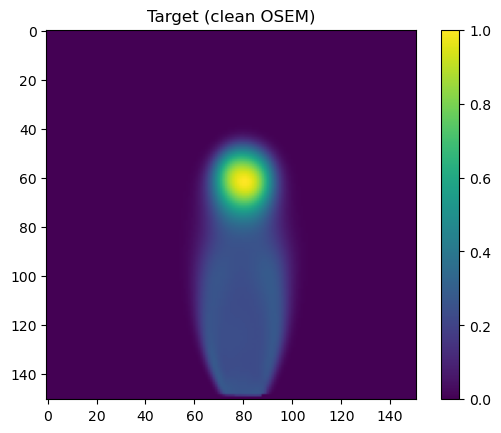

You may need to close Figure 1 window to continue...


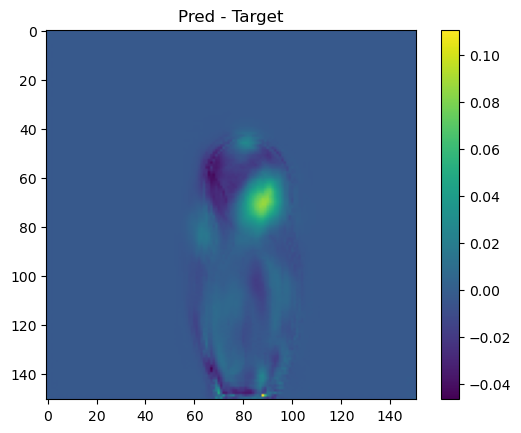

In [ ]:
import numpy as np
import torch

model.eval()
x_in  = torch.from_numpy(X_val[0:1]).float().to(device)
with torch.no_grad():
    y_pred = model(x_in).cpu().numpy()

x0 = X_val[0,0,0]
y0 = Y_val[0,0,0]
p0 = y_pred[0,0,0]

show_2D_array("Input (noisy OSEM)", x0)
show_2D_array("Pred (U-Net)", p0)
show_2D_array("Target (clean OSEM)", y0)
show_2D_array("Pred - Target", p0 - y0)


In [ ]:
import numpy as np
import torch

# 用刚才那一张 val 样本（0号）做数值对比
x0 = X_val[0]          # (1, Z, Y, X)
y0 = Y_val[0]          # (1, Z, Y, X)

# 重新算一次 pred（避免你上面变量名不一致）
model.eval()
with torch.no_grad():
    pred0 = model(torch.from_numpy(x0[None]).float().to(device)).cpu().numpy()[0]  # (1,Z,Y,X)

# --- L1: input->target vs pred->target ---
l1_in  = np.mean(np.abs(x0 - y0))
l1_pred = np.mean(np.abs(pred0 - y0))

print(f"L1(input, target) = {l1_in:.6f}")
print(f"L1(pred,  target) = {l1_pred:.6f}")
print("Improved?" , "YES ✅" if l1_pred < l1_in else "NO ❌")

L1(input, target) = 0.002186
L1(pred,  target) = 0.004150
Improved? NO ❌
